# Non-Historian Authors by Period

Stacked bars — one bar per period, one segment per author. Each segment label shows the author's name, number of works, and total pages.

**Filters**: `selected_english_translation == 1` and `historian == 0`.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

%matplotlib inline
plt.rcParams['figure.dpi'] = 150

INPUT_TSV = Path('../data/perseus_works_wikidata.tsv')

In [2]:
EXCLUDE_AUTHORS = {'unknown', 'pseudo-plutarch'}

df = pd.read_csv(INPUT_TSV, sep='\t')
df = df[(df['selected_english_translation'] == 1) & (df['historian'] == 0)].copy()
df = df[~df['perseus_author'].astype(str).str.strip().str.lower().isin(EXCLUDE_AUTHORS)].copy()
df['year'] = pd.to_numeric(df['author_impact_date'], errors='coerce')
df = df[df['year'].notna()].copy()
df['year'] = df['year'].astype(int)
df['n_pages'] = pd.to_numeric(df['n_pages'], errors='coerce').fillna(0).astype(int)
print(f'Non-historian works (selected English, excluding {sorted(EXCLUDE_AUTHORS)}): {len(df)}')
print(f'Unique authors: {df["perseus_author"].nunique()}')

Non-historian works (selected English, excluding ['pseudo-plutarch', 'unknown']): 391
Unique authors: 39


In [3]:
PERIODS = [
    ('Archaic\n(750\u2013480 BCE)',               -750,  -480),
    ('Classical Athens\n(465\u2013360 BCE)',      -465,  -360),
    ('Late Classical\n(354\u2013165 BCE)',        -354,  -165),
    ('Hellenistic & Early Roman\n(165 BCE \u2013 105 CE)', -165, 105),
    ('High Roman Empire\n(135\u2013205 CE)',       135,   205),
]

def assign_period(year):
    for label, lo, hi in PERIODS:
        if lo <= year <= hi:
            return label
    return None

df['period'] = df['year'].apply(assign_period)
df = df[df['period'].notna()].copy()
print(df['period'].value_counts())

period
Classical Athens\n(465–360 BCE)                  166
High Roman Empire\n(135–205 CE)                   81
Late Classical\n(354–165 BCE)                     80
Hellenistic & Early Roman\n(165 BCE – 105 CE)     35
Archaic\n(750–480 BCE)                            29
Name: count, dtype: int64


In [4]:
by_author = (
    df.groupby(['period', 'perseus_author'])
      .agg(n_works=('file_id', 'count'), total_pages=('n_pages', 'sum'))
      .reset_index()
)

period_totals = (
    by_author.groupby('period')
             .agg(n_authors=('perseus_author', 'nunique'),
                  n_works=('n_works', 'sum'),
                  total_pages=('total_pages', 'sum'))
             .reset_index()
)
period_totals

,period,n_authors,n_works,total_pages
0,Archaic\n(750–480 BCE),7,29,2118
1,Classical Athens\n(465–360 BCE),9,166,7215
2,Hellenistic & Early Roman\n(165 BCE – 105 CE),6,35,1385
3,High Roman Empire\n(135–205 CE),9,81,5530
4,Late Classical\n(354–165 BCE),8,80,5161


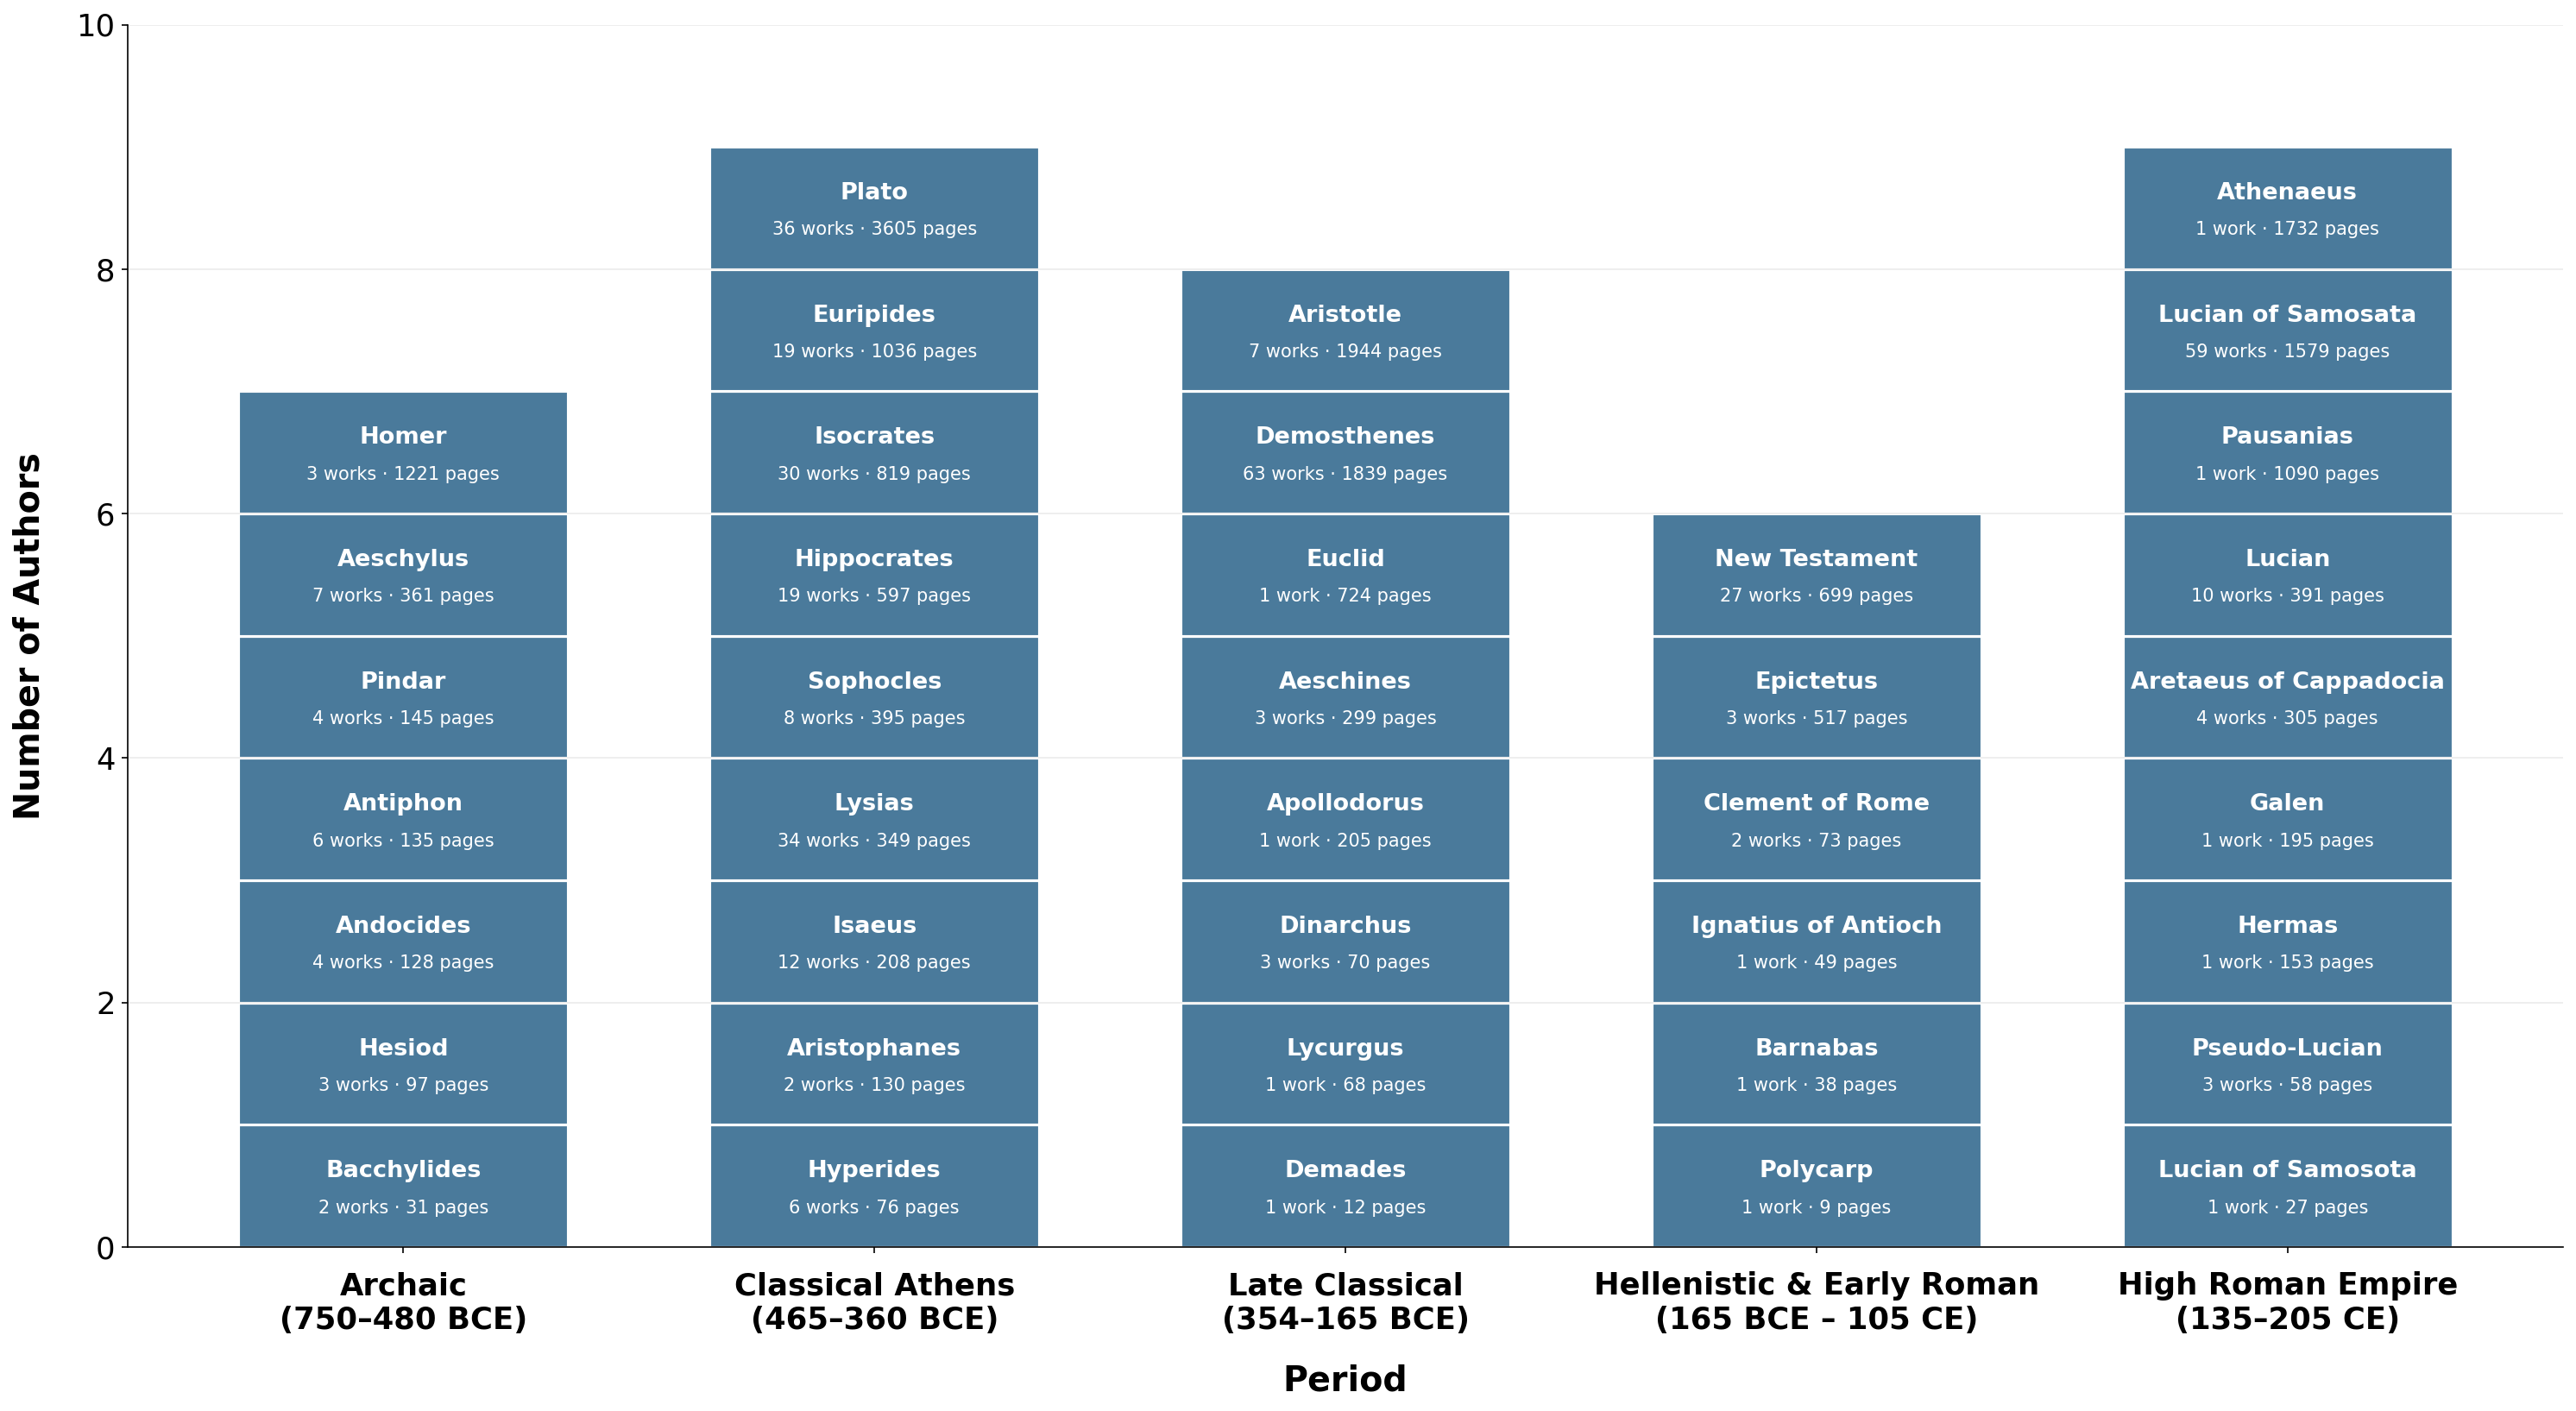

In [5]:
period_order = [p[0] for p in PERIODS]

fig, ax = plt.subplots(figsize=(20, 11))
bar_width = 0.7
bar_color = '#4a7a9b'

max_authors = int(period_totals['n_authors'].max())
y_top = max_authors + 1

for x, period in enumerate(period_order):
    authors = (
        by_author[by_author['period'] == period]
        .sort_values('total_pages', ascending=True)
        .reset_index(drop=True)
    )
    if authors.empty:
        continue
    bottom = 0
    for _, row in authors.iterrows():
        ax.bar(x, 1, bottom=bottom, width=bar_width,
               color=bar_color, edgecolor='white', linewidth=1.5)
        n_works = int(row['n_works'])
        n_pages = int(row['total_pages'])
        works_lbl = '1 work' if n_works == 1 else f'{n_works} works'
        pages_lbl = '1 page' if n_pages == 1 else f'{n_pages} pages'
        ax.text(x, bottom + 0.62, row['perseus_author'],
                ha='center', va='center',
                fontsize=13, fontweight='bold', color='white')
        ax.text(x, bottom + 0.32, f'{works_lbl} \u00b7 {pages_lbl}',
                ha='center', va='center',
                fontsize=10, color='white')
        bottom += 1

ax.set_xticks(range(len(period_order)))
ax.set_xticklabels(period_order, fontsize=17, fontweight='bold')
ax.set_xlabel('Period', fontsize=19, fontweight='bold', labelpad=16)
ax.set_ylabel('Number of Authors', fontsize=19, fontweight='bold', labelpad=16)
ax.tick_params(axis='x', labelsize=17, pad=10)
ax.tick_params(axis='y', labelsize=17)
ax.set_ylim(0, y_top)
ax.set_yticks(range(0, y_top + 1, 2))
ax.grid(axis='y', alpha=0.25)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()